In [1]:
import networkx as nx
from cdlib.algorithms import leiden, louvain, infomap, walktrap
from time import time

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'graph_tool', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [2]:
def tic():
    return time()

def toc(start):
    return time() - start

In [3]:
G = nx.read_graphml("KRvKP_5_updated.graphml")
G = nx.convert_node_labels_to_integers(G)
print(f"n: {G.number_of_nodes()}")
print(f"m: {G.number_of_edges()}")

n: 19617
m: 75160


In [4]:
def save(G, filename):
    reverse_map = {node_id: data["label"] for node_id, data in G.nodes(data=True)}
    G_restored = nx.relabel_nodes(G, reverse_map)
    nx.write_graphml(G, f"{filename}.graphml")

In [5]:
def set_communities_to_graph(G, communities, algorithm_name):
    for i, c in enumerate(communities):
        for u in c:
            G.nodes[u][algorithm_name] = i

algorithms = {"louvain": louvain, "leiden": leiden, "infomap": infomap, "walktrap": walktrap}
results = {k: None for k in algorithms.keys()}

for algorithm_name, algorithm in algorithms.items():
    start = tic()
    try:
        result = algorithm(G)
        set_communities_to_graph(G, result.communities, algorithm_name)
    except TypeError as e:
        G_ = G.to_undirected()
        result = algorithm(G_)
        set_communities_to_graph(G, result.communities, algorithm_name)
    results[algorithm_name] = result
    t = toc(start)
    print(f"{algorithm_name}: {t:.2f}s")

louvain: 8.98s
leiden: 0.97s
infomap: 9.72s
walktrap: 7.71s


In [6]:
save(G, "KRvKP_5_updated_updated")

In [7]:
G.nodes[0]

{'label': '3r4/2k5/5P2/7K/8/8/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 25,
 'Cluster': 10,
 'size': 10.0,
 'r': 0,
 'g': 176,
 'b': 235,
 'x': 18.257175,
 'y': 335.86563,
 'louvain': 8,
 'leiden': 10,
 'infomap': 13,
 'walktrap': 2}

In [8]:
win_frequency = dict()
loss_frequency = dict()

result = results["leiden"]
communities = result.communities
nodes = list(G.nodes())
for i, c in enumerate(communities):
    if len(c)/len(nodes) < 0.025:
        continue
        
    wins = 0
    losses = 0
    for u in c:
        if G.nodes[u]["wdl"] == 2:
            wins += 1
        elif G.nodes[u]["wdl"] == -2:
            losses += 1
    win_frequency[i] = wins/len(c)
    loss_frequency[i] = losses/len(c)

In [9]:
win_frequency = dict(sorted(win_frequency.items(), key=lambda item: -item[1]))
loss_frequency = dict(sorted(loss_frequency.items(), key=lambda item: -item[1]))

In [10]:
win_frequency

{13: 0.9153936545240893,
 11: 0.8641114982578397,
 14: 0.8564705882352941,
 0: 0.7095077038707253,
 12: 0.7069167643610785,
 10: 0.6898954703832753,
 16: 0.5053763440860215,
 3: 0.4659090909090909,
 15: 0.46135552913198574,
 1: 0.4228079612694997,
 2: 0.37220149253731344,
 8: 0.33912037037037035,
 6: 0.27880184331797236,
 4: 0.2759407069555302,
 7: 0.1674364896073903,
 9: 0.13904982618771727,
 19: 0.13822525597269625,
 18: 0.09582689335394126,
 5: 0.09360730593607305,
 17: 0.08333333333333333}

In [11]:
loss_frequency

{19: 0.8447098976109215,
 8: 0.5347222222222222,
 6: 0.533410138248848,
 9: 0.52954808806489,
 2: 0.5167910447761194,
 7: 0.5150115473441108,
 18: 0.27666151468315303,
 5: 0.1187214611872146,
 1: 0.1178052716514255,
 0: 0.10559939872228485,
 4: 0.10376282782212087,
 15: 0.09155766944114149,
 14: 0.07411764705882352,
 16: 0.07168458781362007,
 12: 0.07151230949589683,
 11: 0.07084785133565621,
 3: 0.0625,
 10: 0.04994192799070848,
 13: 0.038777908343125736,
 17: 0.0}

In [17]:
for i, c in enumerate(communities):
    largest = max(nx.weakly_connected_components(G), key=len)
    print(len(largest)/len(G))

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


In [18]:
def get_barycenter(G, community):
    G_ = G.subgraph(community)
    G_ = G_.to_undirected()
    return nx.barycenter(G_)[0]

In [22]:
get_barycenter(G, result.communities[13])

2890

In [23]:
G.nodes[2890]

{'label': '3r4/2k5/5P2/8/8/7K/8/8:b:2',
 'wdl': 2,
 'Modularity Class': 0,
 'Inferred Class': 3,
 'Cluster': 14,
 'size': 10.0,
 'r': 103,
 'g': 82,
 'b': 31,
 'x': 2363.0623,
 'y': 2492.3513,
 'louvain': 14,
 'leiden': 13,
 'infomap': 11,
 'walktrap': 15}

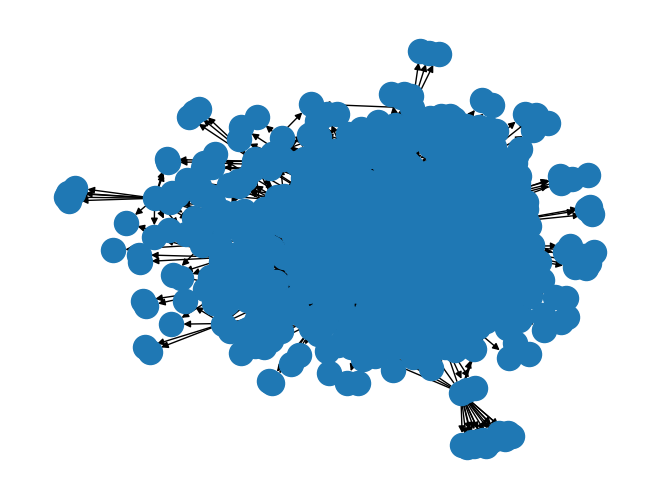

In [24]:
nx.draw(G.subgraph(result.communities[13]))